# Task 1 — Diagnóstico, baselines e ARIMA/SARIMA

**Curso:** Séries Temporais · FGV EMAp · 2026/2

Três séries **diárias** da mesma loja Walmart (recorte M5 `CA_1`), já agregadas:

| Coluna | Série |
|---|---|
| `store_total` | total da loja |
| `FOODS` | categoria alimentos |
| `HOBBIES` | categoria hobbies |

O objetivo é prever os **28 dias** de 2016-03-28 a 2016-04-24 e comparar um
ARIMA/SARIMA contra quatro baselines simples.

## Roteiro

| Seção | Conteúdo |
|---|---|
| 0 | Setup — imports, constantes, configuração de gráficos |
| 1 | Os dados e o split temporal |
| 2 | Diagnóstico — série no tempo, outliers, sazonalidade, STL, estacionariedade, ACF/PACF |
| 3 | Os quatro baselines |
| 4 | Identificação da ordem — `D` pela força sazonal, `d` por KPSS iterativo, `p,q,P,Q` por grid de AICc |
| 5 | Previsão dos 28 dias |
| 6 | Métricas — MAE, RMSE e MASE na validação |
| 7 | Exportação de `previsoes_validacao.csv` e `metricas.csv` |
| 8 | Reprodução |

Rodar o notebook inteiro leva cerca de 6 minutos, quase todos no grid de AICc da
seção 4.

## 0. Setup

Imports, constantes do problema e configuração visual. Tudo que é fixo aparece
aqui uma única vez, para o resto do notebook não repetir número mágico.

Dois pontos sobre o ambiente:

- `torch` é instalado **fora** do `uv` (build ROCm para GPU AMD), então o import
  é protegido: o notebook roda inteiro sem ele. Veja o `README.md`.
- As figuras são salvas em `figuras/` além de aparecerem inline, para o
  diagnóstico ficar legível mesmo sem executar o notebook.

In [24]:
from __future__ import annotations

# --- BLAS em uma thread ----------------------------------------------------
# Duas camadas, porque uma só não cobre os dois modos de execução:
#
#   1. As variáveis de ambiente valem quando o processo é novo — `nbconvert`,
#      `python -m`, kernel recém-reiniciado. O OpenBLAS as lê ao carregar.
#   2. `threadpool_limits` age em tempo de execução, pela API da própria
#      biblioteca. É o que cobre o kernel quente do Jupyter ou do VS Code, em
#      que o numpy já foi importado e as variáveis chegam tarde demais.
#
# Importa para o resultado, não só para o tempo: com OpenBLAS multithread o
# L-BFGS percorre trajetórias diferentes entre execuções e o AICc deixa de ser
# reprodutível (medimos 18,1 e 27807,9 para o mesmo modelo). E sem a segunda
# camada, um "Run All" em kernel reaproveitado roda com 12 threads de BLAS por
# worker: ~84 threads disputando 12 núcleos, e o grid da seção 4 passa de
# 5 minutos para mais de 40.
import os

for _v in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "1")

import itertools
import multiprocessing as mp
import subprocess
import sys
import time
import warnings
from concurrent.futures import ProcessPoolExecutor
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from threadpoolctl import threadpool_info, threadpool_limits
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.sm_exceptions import (
    ConvergenceWarning,
    EstimationWarning,
    InterpolationWarning,
)
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf, adfuller, kpss, pacf

# torch vem de uma instalação ROCm separada; o notebook não depende dele.
try:
    import torch

    TORCH_OK = True
except ImportError:
    TORCH_OK = False

# Segunda camada. A referência é mantida porque o limite vale enquanto o
# objeto viver; os processos filhos herdam o limite pelo fork.
_BLAS = threadpool_limits(limits=1)

ROOT = Path.cwd()
DATA = ROOT / "dados"
FIGS = ROOT / "figuras"
FIGS.mkdir(exist_ok=True)

SERIES = ("store_total", "FOODS", "HOBBIES")
M = 7  # período sazonal: a semana
H = 28  # horizonte da Task 1
VAL_START = pd.Timestamp("2016-03-28")
VAL_END = pd.Timestamp("2016-04-24")
TREINO_FIM = pd.Timestamp("2016-03-27")

# --- busca de ordem --------------------------------------------------------
P_MAX = Q_MAX = 3  # p, q ∈ 0..3
PS_MAX = QS_MAX = 2  # P, Q ∈ 0..2
MAXITER = 200  # o default (50) não converge nas ordens maiores e enviesa o AICc
K_BT = 12  # origens do backtest que decide o D do HOBBIES
N_JOBS = min(6, os.cpu_count() or 1)

_threads_blas = {i["internal_api"]: i["num_threads"] for i in threadpool_info()}
assert all(n == 1 for n in _threads_blas.values()), (
    f"BLAS com mais de uma thread: {_threads_blas}. O grid da seção 4 levaria dezenas "
    "de minutos. Reinicie o kernel e rode de novo."
)

print(f"pandas {pd.__version__} | numpy {np.__version__} | torch disponível: {TORCH_OK}")
print(f"BLAS {_threads_blas} | pool de {N_JOBS} processos | {os.cpu_count()} CPUs")

pandas 3.0.6 | numpy 2.5.3 | torch disponível: False
BLAS {'openblas': 1} | pool de 6 processos | 16 CPUs


In [25]:
# --- paleta e estilo -------------------------------------------------------
# Cores categóricas validadas para daltonismo (ΔE CVD ≥ 9.2 entre todos os pares).
SURFACE = "#fcfcfb"
TINTA = "#0b0b0b"
TINTA_2 = "#52514e"
LINHA = "#d8d7d2"
CORES = {"store_total": "#2a78d6", "FOODS": "#eb6834", "HOBBIES": "#1baf7a"}
DESTAQUE = "#e34948"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 140,
    "savefig.bbox": "tight",
    "figure.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": LINHA,
    "axes.titleweight": "bold",
    "axes.titlesize": 11,
    "axes.titlelocation": "left",
    "axes.labelsize": 9,
    "axes.labelcolor": TINTA_2,
    "text.color": TINTA,
    "xtick.color": TINTA_2,
    "ytick.color": TINTA_2,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "grid.color": "#e6e5e0",
    "grid.linewidth": 0.8,
    "legend.frameon": False,
})


def painel(n=3, altura=2.4, largura=11.0, ncols=1, sharex=True, sharey=False):
    """Uma figura com um painel por série (small multiples)."""
    fig, axes = plt.subplots(
        n, ncols, figsize=(largura, altura * n), sharex=sharex, sharey=sharey
    )
    return fig, np.atleast_1d(axes).ravel()


def salvar(fig, nome: str) -> None:
    fig.tight_layout()
    fig.savefig(FIGS / nome)
    print(f"  → figuras/{nome}")


MESES_PT = ["jan", "fev", "mar", "abr", "mai", "jun",
            "jul", "ago", "set", "out", "nov", "dez"]


def eixo_mes(ax) -> None:
    """Rótulos de mês em português, para o gráfico não misturar idiomas."""
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(
            lambda x, _: f"{MESES_PT[mdates.num2date(x).month - 1]}/{mdates.num2date(x):%y}"
        )
    )

## 1. Os dados e o split temporal

Três arquivos em `data/`:

| Arquivo | Período | Tem `y`? |
|---|---|---|
| `treino.csv` | 2011-01-29 a 2016-03-27 | sim |
| `validacao.csv` | 2016-03-28 a 2016-04-24 | sim — **é o horizonte desta Task** |
| `holdout_datas.csv` | 2016-04-25 a 2016-05-22 | **não**, só as datas |

O `y` do holdout não faz parte desta entrega: ele é o score cego da A2. Por isso
ele aparece aqui só como lista de datas que **não podem** receber previsão.

In [26]:
train = pd.read_csv(DATA / "treino.csv", parse_dates=["date"]).sort_values("date")
val = pd.read_csv(DATA / "validacao.csv", parse_dates=["date"]).sort_values("date")
holdout = pd.read_csv(DATA / "holdout_datas.csv", parse_dates=["date"]).sort_values("date")

train = train.set_index("date").asfreq("D")
val = val.set_index("date").asfreq("D")

print(f"treino    {train.index.min().date()} → {train.index.max().date()}  ({len(train)} dias)")
print(f"validação {val.index.min().date()} → {val.index.max().date()}  ({len(val)} dias)")
print(f"holdout   {holdout['date'].min().date()} → {holdout['date'].max().date()}  ({len(holdout)} datas, sem y)")

treino    2011-01-29 → 2016-03-27  (1885 dias)
validação 2016-03-28 → 2016-04-24  (28 dias)
holdout   2016-04-25 → 2016-05-22  (28 datas, sem y)


### Integridade do split

Checagens que falham alto se algo estiver fora do lugar — é mais barato quebrar
aqui do que descobrir vazamento no fim.

In [27]:
assert train.index.max() == TREINO_FIM, "treino não termina em 2016-03-27"
assert val.index.min() == VAL_START and val.index.max() == VAL_END, "validação fora do horizonte"
assert len(val) == 28, "validação não tem 28 dias"
assert not train.index.has_duplicates and not val.index.has_duplicates
assert train.index.to_series().diff().dropna().eq(pd.Timedelta(days=1)).all(), "buraco de data no treino"
assert train.notna().all().all(), "NaN no treino"
assert train.index.max() < val.index.min() < pd.Timestamp(holdout["date"].min()), "ordem dos blocos errada"
assert set(SERIES) == set(train.columns) == set(val.columns)

print("split íntegro: treino < validação < holdout, sem buracos e sem NaN")

split íntegro: treino < validação < holdout, sem buracos e sem NaN


In [28]:
resumo = pd.DataFrame({
    "n": train.count(),
    "média": train.mean().round(1),
    "desvio": train.std().round(1),
    "mín": train.min(),
    "máx": train.max(),
    "mediana": train.median(),
}).loc[list(SERIES)]
resumo

,n,média,desvio,mín,máx,mediana
store_total,1885,4016.1,990.0,0,6948,3899.0
FOODS,1885,2809.6,701.2,0,5016,2710.0
HOBBIES,1885,457.1,123.6,0,953,458.0


### A regra anti-vazamento

> Se a informação não existiria em **2016-03-27**, ela não entra no treino.

Na prática, três consequências que valem **2,5 pontos** do critério de split:

1. Todo modelo é ajustado **só** com `treino.csv`. A validação nunca é usada no `fit`.
2. `previsoes_validacao.csv` só pode conter datas entre 2016-03-28 e 2016-04-24.
3. Nenhuma data do holdout aparece na entrega.

Como as séries são temporais, não existe embaralhar linhas: a ordem cronológica
é a informação.

## 2. Diagnóstico

Objetivo desta seção: entender **tendência**, **sazonalidade semanal** e
**outliers** antes de escolher qualquer modelo. É daqui que sai a ordem do
SARIMA.

### 2.1 A série no tempo

Primeiro a visão completa, 2011 a 2016. Um painel por série porque as escalas
são muito diferentes (`store_total` roda na casa dos milhares, `HOBBIES` nas
centenas) — sobrepor as três num eixo só esconderia a menor.

  → figuras/01_series_completas.png


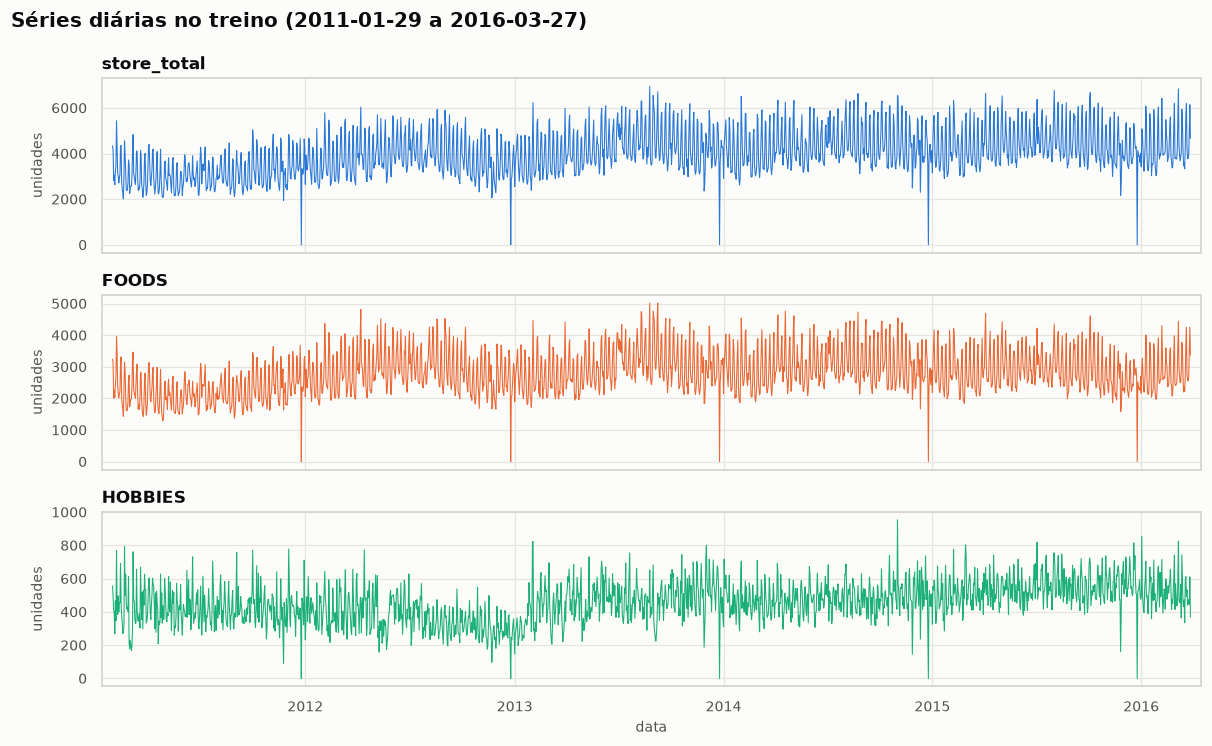

In [29]:
fig, axes = painel(3, altura=2.3)
for ax, s in zip(axes, SERIES):
    ax.plot(train.index, train[s], color=CORES[s], lw=0.7)
    ax.set_title(s)
    ax.set_ylabel("unidades")
    ax.margins(x=0.01)
axes[-1].set_xlabel("data")
fig.suptitle("Séries diárias no treino (2011-01-29 a 2016-03-27)", x=0.0, ha="left",
             fontsize=13, fontweight="bold")
salvar(fig, "01_series_completas.png")
plt.show()

Agora o zoom nos últimos 120 dias do treino, com o início da validação marcado.
É a janela que o modelo realmente "vê" ao prever, e onde a estrutura semanal
fica visível a olho nu.

  → figuras/02_series_zoom.png


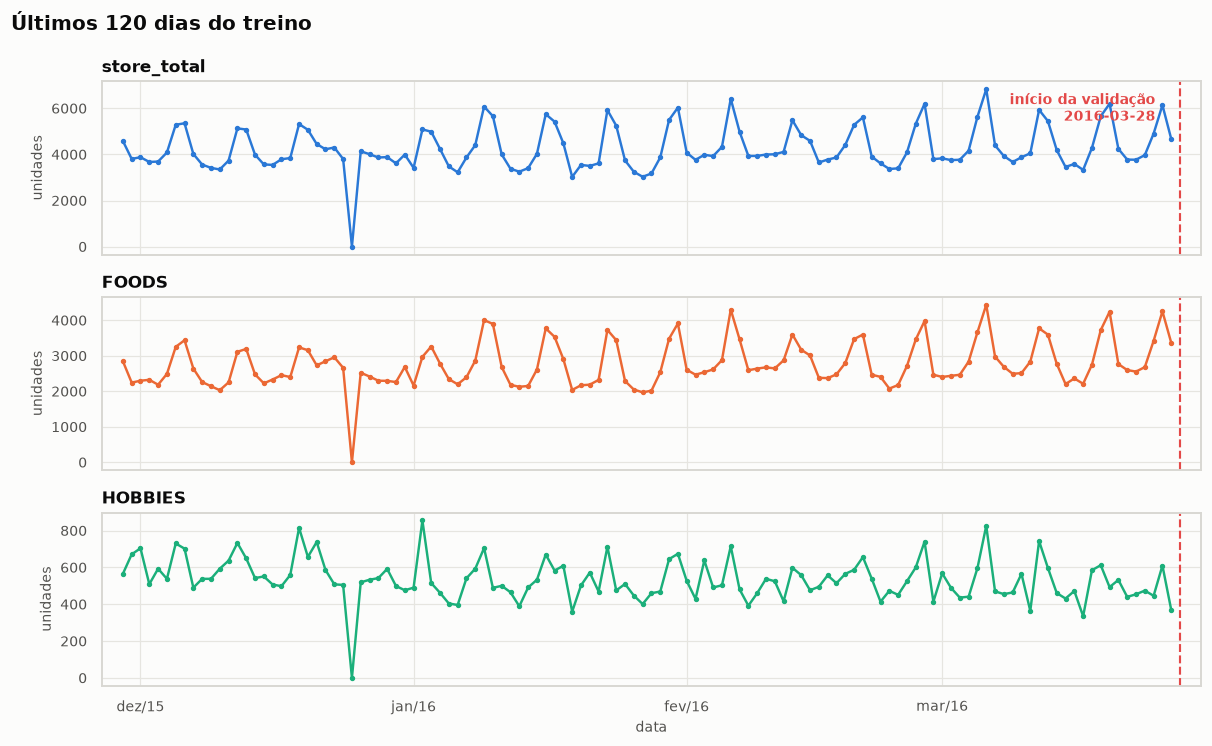

In [30]:
jan_ini = TREINO_FIM - pd.Timedelta(days=119)
fig, axes = painel(3, altura=2.3)
for ax, s in zip(axes, SERIES):
    janela = train.loc[jan_ini:, s]
    ax.plot(janela.index, janela, color=CORES[s], lw=1.6, marker="o", ms=2.5)
    ax.axvline(VAL_START, color=DESTAQUE, lw=1.4, ls="--")
    ax.set_title(s)
    ax.set_ylabel("unidades")
    ax.margins(x=0.02)
axes[0].annotate("início da validação\n2016-03-28", xy=(VAL_START, 0.94),
                 xycoords=("data", "axes fraction"), xytext=(-16, 0),
                 textcoords="offset points", ha="right", va="top",
                 fontsize=9, color=DESTAQUE, fontweight="bold")
eixo_mes(axes[-1])
axes[-1].set_xlabel("data")
fig.suptitle("Últimos 120 dias do treino", x=0.0, ha="left", fontsize=13, fontweight="bold")
salvar(fig, "02_series_zoom.png")
plt.show()

### 2.2 Outliers de calendário

O enunciado avisa que existem zeros de calendário. Vamos localizá-los.

In [31]:
zeros = train[(train[list(SERIES)] == 0).any(axis=1)]
print(f"{len(zeros)} dias com zero em alguma série:\n")
zeros.assign(dia=zeros.index.day_name())

5 dias com zero em alguma série:



,store_total,FOODS,HOBBIES,dia
date,,,,
2011-12-25,0,0,0,Sunday
2012-12-25,0,0,0,Tuesday
2013-12-25,0,0,0,Wednesday
2014-12-25,0,0,0,Thursday
2015-12-25,0,0,0,Friday


São exatamente **5 dias**, todos 25 de dezembro, e as três séries zeram juntas:
a loja fecha no Natal. Não é ruído de medição, é fechamento.

Mas o zero não está sozinho — a semana inteira de festas é um vale. Comparando
`store_total` (média geral ≈ 4027) nos dias ao redor:

In [32]:
anos = range(2011, 2016)
vizinhanca = pd.DataFrame(
    {
        rotulo: [train["store_total"].get(pd.Timestamp(f"{a + salto}-{mmdd}"), np.nan) for a in anos]
        for rotulo, mmdd, salto in [
            ("18/12", "12-18", 0), ("24/12", "12-24", 0), ("25/12", "12-25", 0),
            ("26/12", "12-26", 0), ("01/01", "01-01", 1),
        ]
    },
    index=[f"{a}" for a in anos],
).astype("Int64")
vizinhanca.index.name = "ano"
print(f"média geral de store_total (sem os zeros): {train['store_total'][train['store_total'] > 0].mean():.0f}\n")
vizinhanca

média geral de store_total (sem os zeros): 4027



,18/12,24/12,25/12,26/12,01/01
ano,,,,,
2011,4253,3454,0,3335,2648
2012,3277,3370,0,2862,2552
2013,3453,3458,0,3570,2913
2014,3836,3487,0,3593,3150
2015,3843,3803,0,4137,3418


  → figuras/03_zeros_natal.png


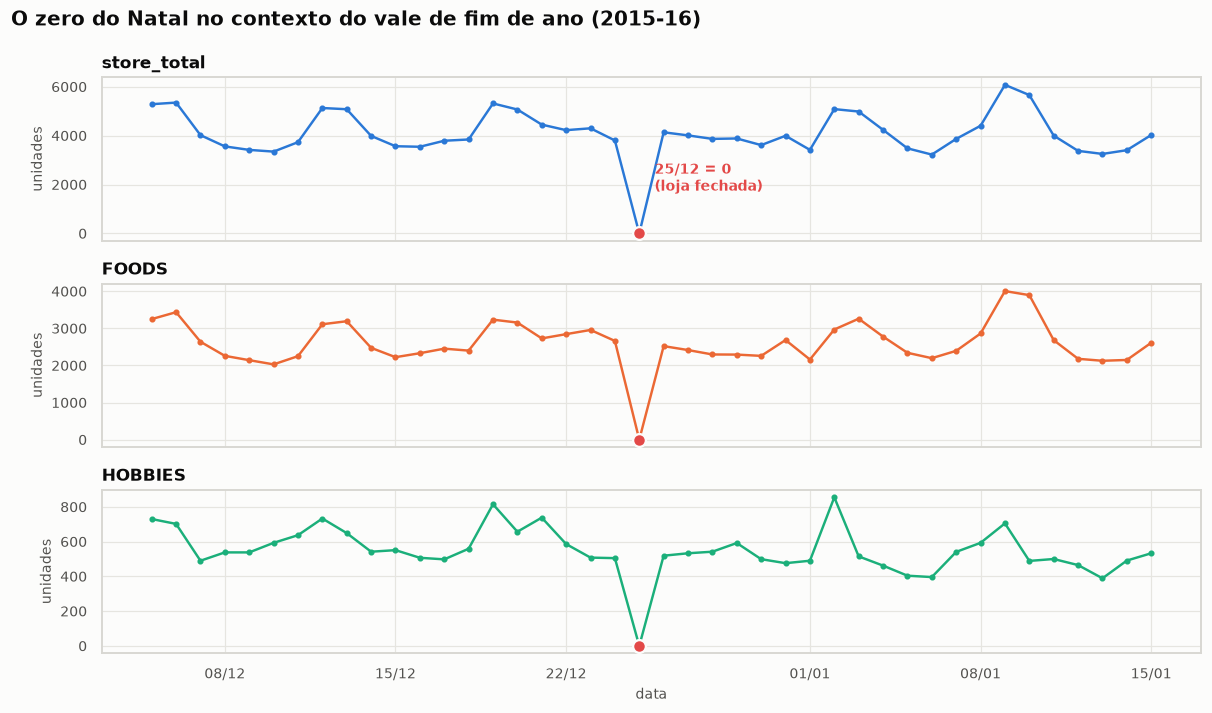

In [33]:
fig, axes = painel(3, altura=2.2)
ini, fim = pd.Timestamp("2015-12-05"), pd.Timestamp("2016-01-15")
for ax, s in zip(axes, SERIES):
    janela = train.loc[ini:fim, s]
    ax.plot(janela.index, janela, color=CORES[s], lw=1.6, marker="o", ms=3)
    natal = pd.Timestamp("2015-12-25")
    ax.scatter([natal], [train.loc[natal, s]], s=70, color=DESTAQUE, zorder=5,
               edgecolor=SURFACE, linewidth=1.5)
    ax.set_title(s)
    ax.set_ylabel("unidades")
axes[0].annotate("25/12 = 0\n(loja fechada)", xy=(pd.Timestamp("2015-12-25"), 0),
                 xytext=(10, 28), textcoords="offset points", fontsize=9,
                 color=DESTAQUE, fontweight="bold")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
axes[-1].set_xlabel("data")
fig.suptitle("O zero do Natal no contexto do vale de fim de ano (2015-16)",
             x=0.0, ha="left", fontsize=13, fontweight="bold")
salvar(fig, "03_zeros_natal.png")
plt.show()

#### Decisão: interpolar os zeros, mas só para o SARIMA

O zero está a cerca de **4 desvios-padrão** abaixo da média. Na verossimilhança
gaussiana do SARIMA ele entra ao quadrado, então um único ponto desses pesa como
~17 pontos normais. Com diferenciação regular e sazonal, cada zero vira um par de
choques (queda + repique). Isso tem três efeitos ruins:

1. **Atenua o ACF/PACF** — o outlier infla a variância no denominador da
   autocorrelação, puxando todos os lags em direção a zero. São justamente esses
   gráficos que usamos para escolher a ordem.
2. **Infla a variância dos resíduos**, alargando os intervalos de previsão.
3. **Distorce o AIC**, que pode premiar a ordem que melhor absorve o Natal em vez
   da que melhor modela a semana.

Então criamos uma cópia interpolada para a identificação e o ajuste do SARIMA.
**Baselines e métricas continuam no dado cru** — a escala do MASE, em particular,
é obrigatoriamente calculada do CSV cru, para bater com a correção.

**Por que interpolação linear e não a média de ±7 dias?** Porque `25/12 + 7 = 01/01`,
que também é dia atípico (tabela acima: 2552 a 3418, contra média de 4027). A
interpolação linear usa 24/12 e 26/12, ambos dentro da mesma semana de festas —
vizinhança mais representativa. Repare na tabela abaixo que os valores
interpolados ficam na faixa dos 3100-3900, ou seja, **preservam o vale** de fim
de ano e removem só o zero artificial.

In [34]:
train_fit = train.copy()
train_fit[list(SERIES)] = train_fit[list(SERIES)].mask(train_fit[list(SERIES)] == 0).interpolate()

comparacao = pd.concat(
    [train.loc[zeros.index, list(SERIES)].add_suffix(" cru"),
     train_fit.loc[zeros.index, list(SERIES)].round(0).astype(int).add_suffix(" interp")],
    axis=1,
)[[f"{s} {k}" for s in SERIES for k in ("cru", "interp")]]
print("train      = dado cru      → baselines, métricas, escala do MASE")
print("train_fit  = interpolado   → ACF/PACF e ajuste do SARIMA\n")
comparacao

train      = dado cru      → baselines, métricas, escala do MASE
train_fit  = interpolado   → ACF/PACF e ajuste do SARIMA



,store_total cru,store_total interp,FOODS cru,FOODS interp,HOBBIES cru,HOBBIES interp
date,,,,,,
2011-12-25,0,3394,0,2559,0,408
2012-12-25,0,3116,0,2388,0,222
2013-12-25,0,3514,0,2552,0,409
2014-12-25,0,3540,0,2488,0,384
2015-12-25,0,3970,0,2592,0,512


In [35]:
# Efeito da interpolação na autocorrelação — é o que motiva a decisão.
efeito = pd.DataFrame(
    {
        s: {
            "ACF(1) cru": acf(train[s], nlags=1)[1],
            "ACF(1) interp": acf(train_fit[s], nlags=1)[1],
            "ACF(7) cru": acf(train[s], nlags=7)[7],
            "ACF(7) interp": acf(train_fit[s], nlags=7)[7],
        }
        for s in SERIES
    }
).round(4)
efeito

,store_total,FOODS,HOBBIES
ACF(1) cru,0.6172,0.6102,0.4845
ACF(1) interp,0.6350,0.6288,0.4949
ACF(7) cru,0.8124,0.7790,0.5247
ACF(7) interp,0.8355,0.8007,0.5336
